**1. Dataset Overview**

**Convention:** Filename consists of 7 parts(numerical identifiers).

**Filename identifiers:** 

    - Modality (01 = full-AV, 02 = video-only, 03 = audio-only).

    - Vocal channel (01 = speech, 02 = song).

    - Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).

    - Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.

    - Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").

    - Repetition (01 = 1st repetition, 02 = 2nd repetition).

    - Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

In [2]:
!pip install librosa numpy matplotlib seaborn torch pandas scikit-learn pydub

  Using cached numpy-2.3.4-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cach

In [3]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import pandas as pd
import os
from pydub import AudioSegment

c:\Users\enapa\anaconda3\envs\speech\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [4]:
# from torchvision import transforms, datasets, models
# from torch.utils.data import DataLoader

In [10]:
path = "C:\\Users\\enapa\\Desktop\\Academic City\\Level 400\\Speech Processing\\All-actors"

print("Path to files:", path)
print("Number of files:", len(os.listdir(path)))

Path to files: C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors
Number of files: 1440


In [11]:
sound_files_paths = []
emotions_classes = []
emotion_intensity_classes = []
statements_classes = []
repitition_classes = []

In [12]:
for file in os.listdir(path):
    if file.endswith(".wav") == False:
        audio = AudioSegment.from_file(os.path.join(path, file))
        audio.export(os.path.join(path, file.split(".")[0] + ".wav"), format="wav")
        os.remove(os.path.join(path, file))
    if file.endswith(".wav"):
        sound_files_paths.append(os.path.join(path, file))
        emotions_classes.append(file.split("-")[2])
        statements_classes.append(file.split("-")[4])
        emotion_intensity_classes.append(file.split("-")[3])
        repitition_classes.append(file.split("-")[5].split(".")[0])
    else:
        continue

In [13]:
# Defining filename identifiers
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',  
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}
emotion_intensity = {
    '01': 'normal',
    '02': 'strong'
}
statements = {
    '01': 'Kids are talking by the door',
    '02': 'Dogs are sitting by the door'
}
repitition = {
    '01': '1st',
    '02': '2nd'
}

In [14]:
print("Number of sound files:", len(sound_files_paths))

Number of sound files: 1440


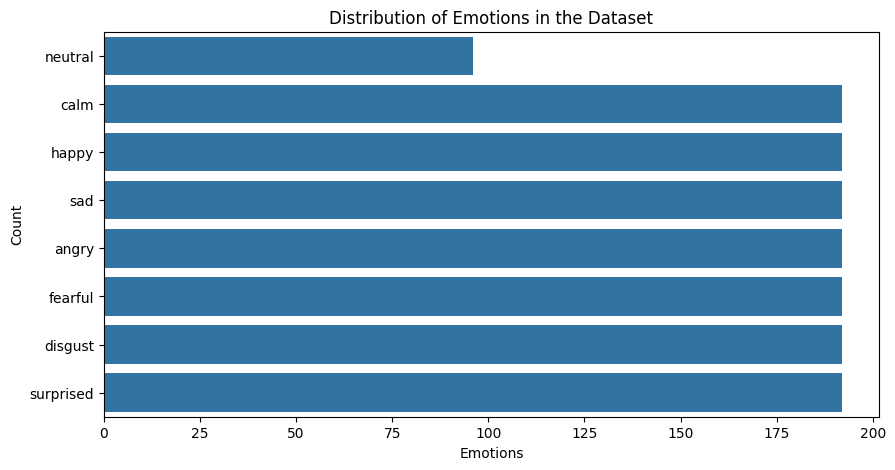

The count of each emotion intensity:
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [15]:
# Showing the count distribution of emotions using their names from the dicionary
emotion_names = [emotions[emo] for emo in emotions_classes]
plt.figure(figsize=(10, 5))
sns.countplot(emotion_names, order=list(emotions.values()))
plt.title("Distribution of Emotions in the Dataset")
plt.xlabel("Emotions")
plt.ylabel("Count")
plt.show()

print("The count of each emotion intensity:")
print(pd.Series(emotion_names).value_counts())
plt.show()

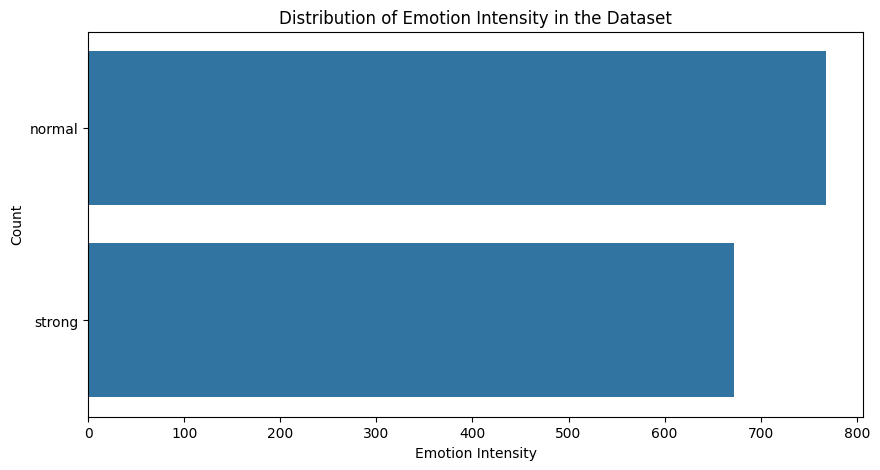

The count of each emotion intensity:
normal    768
strong    672
Name: count, dtype: int64


In [16]:
# Showing the count distribution of emotion intensity
emotion_intensity_names = [emotion_intensity[inten] for inten in emotion_intensity_classes]
plt.figure(figsize=(10, 5))
sns.countplot(emotion_intensity_names, order=list(emotion_intensity.values()))
plt.title("Distribution of Emotion Intensity in the Dataset")
plt.xlabel("Emotion Intensity")
plt.ylabel("Count")
plt.show()

print("The count of each emotion intensity:")
print(pd.Series(emotion_intensity_names).value_counts())
plt.show()

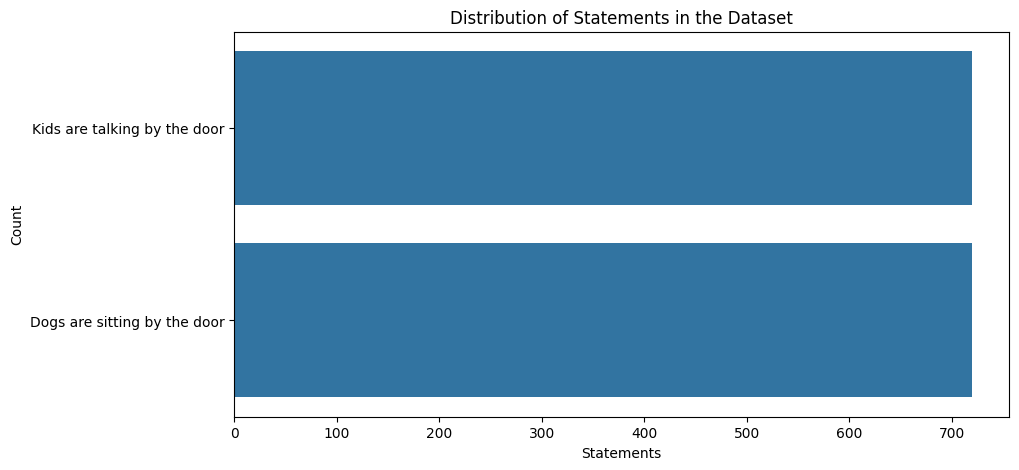

The count of each statement:
Kids are talking by the door    720
Dogs are sitting by the door    720
Name: count, dtype: int64


In [17]:
# Count distribution of statements
statement_names = [statements[stat] for stat in statements_classes]
plt.figure(figsize=(10, 5))
sns.countplot(statement_names, order=list(statements.values()))
plt.title("Distribution of Statements in the Dataset")
plt.xlabel("Statements")
plt.ylabel("Count")
plt.show()

print("The count of each statement:")
print(pd.Series(statement_names).value_counts())
plt.show()

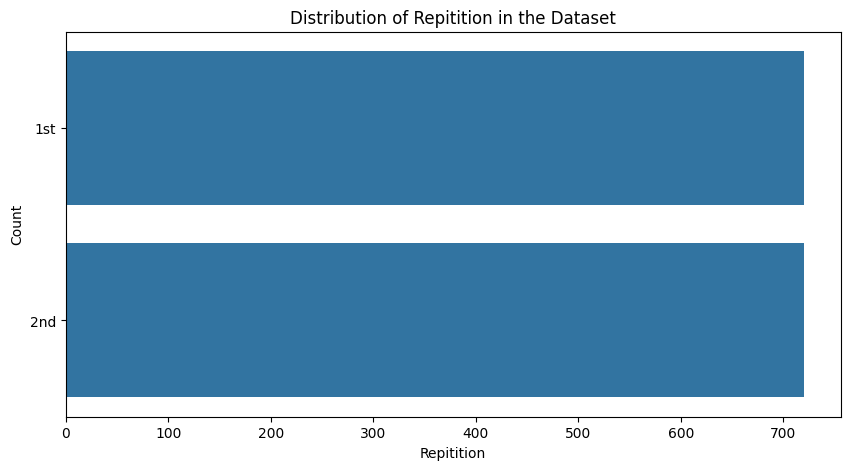

The count of each repitition:
1st    720
2nd    720
Name: count, dtype: int64


In [18]:
# Distribution of repitition
repitition_names = [repitition[rep] for rep in repitition_classes]
plt.figure(figsize=(10, 5))
sns.countplot(repitition_names, order=list(repitition.values()))
plt.title("Distribution of Repitition in the Dataset")
plt.xlabel("Repitition")
plt.ylabel("Count")
plt.show()

print("The count of each repitition:")
print(pd.Series(repitition_names).value_counts())
plt.show()

In [19]:
df = pd.DataFrame({
    'file_path': sound_files_paths,
    'emotion': emotion_names,
    'emotion_intensity': emotion_intensity_names,
    'statement': statement_names,
    'repitition': repitition_names
})

In [20]:
df.tail()

,file_path,emotion,emotion_intensity,statement,repitition
1435,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd
1436,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd
1437,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd
1438,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd
1439,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   file_path          1440 non-null   object
 1   emotion            1440 non-null   object
 2   emotion_intensity  1440 non-null   object
 3   statement          1440 non-null   object
 4   repitition         1440 non-null   object
dtypes: object(5)
memory usage: 56.4+ KB


In [ ]:
# Converting the categorical labels to numerical labels using dictionary
emotion_to_index = {v: k for k, v in emotions.items()}
df['emotion_label'] = df['emotion'].map(emotion_to_index).astype(int)
df['repitition_label'] = df['repitition'].map({'1st': 1, '2nd': 2}).astype(int)
df['statement_label'] = df['statement'].map({v: k for k, v in statements.items()}).astype(int)
df['emotion_intensity_label'] = df['emotion_intensity'].map({'normal': 1, 'strong': 2}).astype(int)

In [23]:
df.tail()

,file_path,emotion,emotion_intensity,statement,repitition,emotion_label,repitition_label,statement_label,emotion_intensity_label
1435,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd,8,2,2,2
1436,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd,8,2,2,2
1437,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd,8,2,2,2
1438,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd,8,2,2,2
1439,C:\Users\enapa\Desktop\Academic City\Level 400...,surprised,strong,Dogs are sitting by the door,2nd,8,2,2,2


In [43]:
#Using SVM, CNN-LSTM and MLP for Speech Emotion Recognition
#Creating models and training them on the multiple features extracted from the audio files
import torch.optim as optim
from sklearn import svm 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA


In [ ]:
#Extracting spectrograms, MFCCs and Chroma features and saving in files

for index, row in df.iterrows():
    file_path = row['file_path']
    y, sr = audioread_load(file_path, sr=None)
    
    # Extracting MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_path = f"preprocessed_mfccs/mfcc_actor_{file_path.split('-')[0]}_{file_path.split('-')[1]}_{file_path.split('-')[2]}_{file_path.split('-')[3]}_{file_path.split('-')[4]}_{file_path.split('-')[5].split('.')[0]}.npy"
    np.save(mfcc_path, mfcc)
    
    # Extracting Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_path = f"preprocessed_chromas/chroma_actor_{file_path.split('-')[0]}_{file_path.split('-')[1]}_{file_path.split('-')[2]}_{file_path.split('-')[3]}_{file_path.split('-')[4]}_{file_path.split('-')[5].split('.')[0]}.npy"
    np.save(chroma_path, chroma)
    
    # Extracting Spectrogram as an image
    spec = librosa.feature.melspectrogram(y=y, sr=sr)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    

C:\Users\enapa\AppData\Local\Temp\ipykernel_13120\1765545189.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_ret = librosa.load(path, sr=sr, mono=True)


Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-01.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-02.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-03.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-04.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-05.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-06.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-07.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Level 400\Speech Processing\All-actors\03-01-01-01-01-01-08.wav: 
Failed to load C:\Users\enapa\Desktop\Academic City\Leve